# 04. Контрольований експеримент з висотою

Цей notebook **не змінює baseline** `fusion_v1` і не підбирає параметри за dense GPS. Він відтворює одну перевірену гіпотезу: у baseline згладжений барометр вирівнювався до `p0` під час набору висоти, тому затримка causal-фільтра перетворювалася на постійний вертикальний зсув.

Порядок роботи:

1. перевірити WSL/kernel і шляхи;
2. побудувати causal barometer-only варіанти `legacy_filtered_at_start` та `corrected_raw_at_start_filter_reset`;
3. оцінити їх через dense GPS лише **після** побудови сигналів (offline diagnostics);
4. за замовчуванням перевикористати вже завершений окремий GTSAM run;
5. порівняти raw/exported висоту та переконатися, що XY і кількість факторів не змінилися.

> `RUN_GTSAM = False` є навмисним запобіжником. Зміна на `True` дозволяє запуск лише в порожній експериментальний каталог; неповний або чужий каталог не перезаписується.

In [1]:
from __future__ import annotations

from datetime import datetime, timezone
import hashlib
import json
import os
from pathlib import Path
import platform
import sys
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

if platform.system() != "Linux":
    raise RuntimeError(
        "Оберіть kernel 'Project CV (ROS 2 Humble)' з WSL Jupyter server; "
        f"поточна ОС: {platform.system()}"
    )

source_env = os.environ.get("PROJECT_CV_SOURCE")
artifacts_env = os.environ.get("PROJECT_CV_ARTIFACTS")
if not source_env or not artifacts_env:
    raise RuntimeError(
        "Kernel не має PROJECT_CV_SOURCE/PROJECT_CV_ARTIFACTS. "
        "Перезапустіть WSL Jupyter через environment/windows/jupyter.ps1."
    )

PROJECT_ROOT = Path(source_env).expanduser().resolve()
ARTIFACTS_ROOT = Path(artifacts_env).expanduser().resolve()
SRC_ROOT = PROJECT_ROOT / "src"
for label, path in {
    "PROJECT_ROOT": PROJECT_ROOT,
    "ARTIFACTS_ROOT": ARTIFACTS_ROOT,
    "SRC_ROOT": SRC_ROOT,
}.items():
    if not path.is_dir():
        raise FileNotFoundError(f"{label} не існує: {path}")

if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from project_cv.experiments.runners.fusion_experiment_runner import (
    BASELINE_CELL_SHA256,
    EXPECTED_OUTPUTS,
    run_fusion_experiment,
)
from project_cv.experiments.height.height_experiments import (
    CAUSAL_PREVIOUS_MODE,
    OFFLINE_INTERPOLATION_MODE,
    CausalHeightFilterConfig,
    EvaluationWindow,
    align_height_to_dense_gps,
    build_and_compare_alignment_variants,
    save_height_comparison,
    summarize_height_alignment,
)

BASELINE_ROOT = ARTIFACTS_ROOT / "fusion_v1"
BASELINE_WORK_DIR = BASELINE_ROOT / "work"
BASELINE_GTSAM_DIR = BASELINE_ROOT / "gtsam"
EXPERIMENT_ROOT = ARTIFACTS_ROOT / "height_experiments_v1" / "baro_alignment_v1"
DIAGNOSTIC_DIR = EXPERIMENT_ROOT / "diagnostic"
CORRECTED_GTSAM_DIR = EXPERIMENT_ROOT / "raw_start_reset" / "gtsam"
COMPARISON_DIR = EXPERIMENT_ROOT / "comparison"

assert BASELINE_ROOT not in CORRECTED_GTSAM_DIR.parents
display(pd.DataFrame({
    "item": ["Python", "project", "artifacts", "experiment"],
    "value": [sys.version.split()[0], PROJECT_ROOT, ARTIFACTS_ROOT, EXPERIMENT_ROOT],
}))

,item,value
0,Python,3.10.12
1,project,/mnt/c/Users/fedor/Desktop/code/project_cv/pro...
2,artifacts,/home/fedor/project_cv_runtime/artifacts
3,experiment,/home/fedor/project_cv_runtime/artifacts/heigh...


## 1. Незмінний baseline та діагностичні вікна

`p0`, активний часовий інтервал і параметри фільтра беруться з baseline summary. `baro_corrected.csv` та `gps_ref_enu.csv` беруться з уже підготовленого `fusion_v1/work`; MCAP повторно не читається. Dense GPS нижче є тільки еталоном для метрик і не потрапляє у GTSAM як фактор.

In [2]:
BASELINE_SUMMARY_PATH = BASELINE_GTSAM_DIR / "gtsam_incremental_fixedlag_summary.json"
BASELINE_OUTPUT_PATH = BASELINE_GTSAM_DIR / "synthetic_gps_5hz_gtsam_fixedlag.csv"
BASELINE_NODES_PATH = BASELINE_GTSAM_DIR / "gtsam_incremental_fixedlag_nodes.csv"
BARO_PATH = BASELINE_WORK_DIR / "baro_corrected.csv"
GPS_REFERENCE_PATH = BASELINE_WORK_DIR / "gps_ref_enu.csv"

required_inputs = (
    BASELINE_SUMMARY_PATH,
    BASELINE_OUTPUT_PATH,
    BASELINE_NODES_PATH,
    BARO_PATH,
    GPS_REFERENCE_PATH,
)
missing = [str(path) for path in required_inputs if not path.is_file()]
if missing:
    raise FileNotFoundError("Відсутні baseline inputs: " + ", ".join(missing))

baseline_summary = json.loads(BASELINE_SUMMARY_PATH.read_text(encoding="utf-8"))
barometer = pd.read_csv(BARO_PATH)
dense_gps = pd.read_csv(GPS_REFERENCE_PATH)

active_start_sec = float(baseline_summary["active_t_start"])
active_end_sec = float(baseline_summary["active_t_end"])
p0_u_m = float(baseline_summary["p0_enu"][2])
active_mid_sec = 0.5 * (active_start_sec + active_end_sec)
EVALUATION_WINDOWS = (
    EvaluationWindow("active_full", active_start_sec, active_end_sec),
    EvaluationWindow("after_20s_warmup", active_start_sec + 20.0, active_end_sec),
    EvaluationWindow("first_half", active_start_sec, active_mid_sec),
    EvaluationWindow("held_out_second_half", active_mid_sec, active_end_sec),
)

assert active_end_sec > active_start_sec
assert baseline_summary["p0_source"] == "gps1_past_sample"
assert int(baseline_summary["failed_updates"]) == 0
display(pd.DataFrame({
    "active_start_sec": [active_start_sec],
    "active_end_sec": [active_end_sec],
    "p0_u_m": [p0_u_m],
    "barometer_rows": [len(barometer)],
    "dense_gps_rows": [len(dense_gps)],
}))

,active_start_sec,active_end_sec,p0_u_m,barometer_rows,dense_gps_rows
0,146.891953,1276.743287,5.98,11918,9202


In [3]:
filter_config = CausalHeightFilterConfig(
    median_window_samples=11,
    mean_window_samples=11,
    iir_tau_sec=0.8,
)
barometer_comparison = build_and_compare_alignment_variants(
    barometer,
    dense_gps,
    active_start_sec=active_start_sec,
    active_end_sec=active_end_sec,
    p0_u_m=p0_u_m,
    p0_source=str(baseline_summary["p0_source"]),
    config=filter_config,
    windows=EVALUATION_WINDOWS,
)
diagnostic_files = save_height_comparison(
    barometer_comparison,
    DIAGNOSTIC_DIR,
    prefix="height_alignment",
)

causal_diagnostic = barometer_comparison.metrics.loc[
    barometer_comparison.metrics["matching_mode"] == CAUSAL_PREVIOUS_MODE,
    ["scope", "series", "n", "bias_u_m", "rmse_u_m", "mae_u_m", "p95_abs_u_m"],
].reset_index(drop=True)
sample_counts = causal_diagnostic.pivot(index="scope", columns="series", values="n")
if not sample_counts.nunique(axis=1).eq(1).all():
    raise RuntimeError("Barometer variants оцінено на різній кількості reference samples")
display(causal_diagnostic)
print("Saved diagnostic summary:", diagnostic_files["summary"])

,scope,series,n,bias_u_m,rmse_u_m,mae_u_m,p95_abs_u_m
0,active_full,legacy_filtered_at_start,8649,5.130256,5.759641,5.158593,9.341807
1,after_20s_warmup,legacy_filtered_at_start,8502,5.219239,5.809007,5.242265,9.356640
2,first_half,legacy_filtered_at_start,4345,6.389495,6.914144,6.432022,9.804859
3,held_out_second_half,legacy_filtered_at_start,4304,3.859021,4.289772,3.873034,7.025595
4,active_full,corrected_raw_at_start_filter_reset,8649,1.815792,3.181201,2.532299,6.023760
5,after_20s_warmup,corrected_raw_at_start_filter_reset,8502,1.901193,3.180981,2.522076,6.038594
6,first_half,corrected_raw_at_start_filter_reset,4345,3.078581,4.046939,3.526316,6.486813
7,held_out_second_half,corrected_raw_at_start_filter_reset,4304,0.540974,1.950067,1.528813,3.790951


Saved diagnostic summary: /home/fedor/project_cv_runtime/artifacts/height_experiments_v1/baro_alignment_v1/diagnostic/height_alignment_summary.json


## 2. Окремий GTSAM run: безпечне повторне використання

Готовий результат очікується у `height_experiments_v1/baro_alignment_v1/raw_start_reset/gtsam`. Manifest має засвідчити `status=completed`, правильний variant, hash frozen fusion-cell та незмінні hashes підготовлених inputs.

Щоб навмисно виконати run з нуля, каталог output має бути відсутнім або порожнім і потрібно змінити `RUN_GTSAM` на `True`. Існуючі результати ця клітинка не перезаписує.

In [4]:
RUN_GTSAM = False
GTSAM_VARIANT = "raw_start_reset"
MANIFEST_PATH = CORRECTED_GTSAM_DIR / "experiment_manifest.json"

def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def load_completed_manifest(path: Path) -> dict[str, Any] | None:
    if not path.is_file():
        return None
    payload = json.loads(path.read_text(encoding="utf-8"))
    if payload.get("status") != "completed" or payload.get("variant") != GTSAM_VARIANT:
        return None
    return payload

existing_manifest = load_completed_manifest(MANIFEST_PATH)
if RUN_GTSAM:
    if CORRECTED_GTSAM_DIR.exists() and any(CORRECTED_GTSAM_DIR.iterdir()):
        if existing_manifest is None:
            raise FileExistsError(
                f"Непорожній output не є завершеним {GTSAM_VARIANT}: {CORRECTED_GTSAM_DIR}"
            )
        print("Завершений run вже існує; безпечно перевикористовую його.")
    else:
        run_fusion_experiment(
            GTSAM_VARIANT,
            source_root=PROJECT_ROOT,
            artifacts_root=ARTIFACTS_ROOT,
            output_dir=CORRECTED_GTSAM_DIR,
        )
        existing_manifest = load_completed_manifest(MANIFEST_PATH)
elif existing_manifest is None:
    raise FileNotFoundError(
        f"Немає завершеного run у {CORRECTED_GTSAM_DIR}. "
        "Для явного запуску встановіть RUN_GTSAM=True."
    )

experiment_manifest = load_completed_manifest(MANIFEST_PATH)
if experiment_manifest is None:
    raise RuntimeError("GTSAM experiment не завершився коректно")
if experiment_manifest["baseline_cell_sha256"] != BASELINE_CELL_SHA256:
    raise RuntimeError("Experiment побудовано не з поточної frozen fusion-cell")

missing_outputs = [
    name for name in EXPECTED_OUTPUTS
    if not (CORRECTED_GTSAM_DIR / name).is_file()
]
if missing_outputs:
    raise FileNotFoundError("Experiment outputs відсутні: " + ", ".join(missing_outputs))

hash_mismatches = []
for filename, expected_hash in experiment_manifest["input_sha256"].items():
    input_path = BASELINE_WORK_DIR / filename
    actual_hash = sha256_file(input_path) if input_path.is_file() else "missing"
    if actual_hash != expected_hash:
        hash_mismatches.append(filename)
if hash_mismatches:
    raise RuntimeError("Prepared baseline inputs змінилися: " + ", ".join(hash_mismatches))

print("Reusing completed experiment:", CORRECTED_GTSAM_DIR)
print("Elapsed during original run, s:", round(float(experiment_manifest["elapsed_sec"]), 2))

Reusing completed experiment: /home/fedor/project_cv_runtime/artifacts/height_experiments_v1/baro_alignment_v1/raw_start_reset/gtsam
Elapsed during original run, s: 41.21


## 3. Чесне порівняння fusion outputs

Порівнюються чотири вертикальні ряди: baseline/corrected × raw/exported. Для звіту зберігаються як offline linear interpolation, так і причинне зіставлення з останнім output sample (`causal ZOH`). Рішення приймається за causal-метрикою.

Окремі guardrails перевіряють: однакові counts факторів/вузлів, `failed_updates=0`, однакові timestamps та практично незмінну XY-траєкторію.

In [5]:
CORRECTED_SUMMARY_PATH = CORRECTED_GTSAM_DIR / "gtsam_incremental_fixedlag_summary.json"
CORRECTED_OUTPUT_PATH = CORRECTED_GTSAM_DIR / "synthetic_gps_5hz_gtsam_fixedlag.csv"
CORRECTED_NODES_PATH = CORRECTED_GTSAM_DIR / "gtsam_incremental_fixedlag_nodes.csv"

corrected_summary = json.loads(CORRECTED_SUMMARY_PATH.read_text(encoding="utf-8"))
baseline_output = pd.read_csv(BASELINE_OUTPUT_PATH)
corrected_output = pd.read_csv(CORRECTED_OUTPUT_PATH)

series_inputs = {
    "baseline_exported": (baseline_output, "u"),
    "baseline_raw": (baseline_output, "u_raw"),
    "corrected_exported": (corrected_output, "u"),
    "corrected_raw": (corrected_output, "u_raw"),
}
aligned_tables = []
height_metric_rows: list[dict[str, Any]] = []
for series_name, (frame, height_column) in series_inputs.items():
    for matching_mode in (OFFLINE_INTERPOLATION_MODE, CAUSAL_PREVIOUS_MODE):
        aligned = align_height_to_dense_gps(
            frame,
            dense_gps,
            series_name=series_name,
            matching_mode=matching_mode,
            sample_height_column=height_column,
            evaluation_start_sec=active_start_sec,
            evaluation_end_sec=active_end_sec,
        )
        aligned_tables.append(aligned)
        for window in EVALUATION_WINDOWS:
            height_metric_rows.append(summarize_height_alignment(aligned, window=window))

fusion_alignments = pd.concat(aligned_tables, ignore_index=True)
fusion_height_metrics = pd.DataFrame(height_metric_rows)
COMPARISON_DIR.mkdir(parents=True, exist_ok=True)
fusion_alignments.to_csv(COMPARISON_DIR / "fusion_height_aligned_samples.csv", index=False)
fusion_height_metrics.to_csv(COMPARISON_DIR / "fusion_height_metrics.csv", index=False)

COUNT_KEYS = (
    "nodes_saved",
    "used_starlink_sparse_gps",
    "used_vision_velocity",
    "discarded_vision_velocity",
    "used_baro",
    "smoother_updates",
    "marginalized_nodes",
    "failed_updates",
)
count_guardrails = pd.DataFrame([
    {
        "metric": key,
        "baseline": int(baseline_summary[key]),
        "corrected": int(corrected_summary[key]),
        "equal": int(baseline_summary[key]) == int(corrected_summary[key]),
    }
    for key in COUNT_KEYS
])
if not count_guardrails["equal"].all():
    raise RuntimeError("Змінилася кількість вузлів або факторів")
if int(corrected_summary["failed_updates"]) != 0:
    raise RuntimeError("Corrected fusion має failed updates")

baseline_nodes = pd.read_csv(BASELINE_NODES_PATH, usecols=["idx", "tr", "e", "n"])
corrected_nodes = pd.read_csv(CORRECTED_NODES_PATH, usecols=["idx", "tr", "e", "n"])
node_pairs = baseline_nodes.merge(
    corrected_nodes,
    on="idx",
    suffixes=("_baseline", "_corrected"),
    validate="one_to_one",
)
if len(node_pairs) != int(baseline_summary["nodes_saved"]):
    raise RuntimeError("Не всі graph nodes мають пару")
max_time_difference_sec = float(
    np.max(np.abs(node_pairs["tr_corrected"] - node_pairs["tr_baseline"]))
)
max_abs_e_difference_m = float(
    np.max(np.abs(node_pairs["e_corrected"] - node_pairs["e_baseline"]))
)
max_abs_n_difference_m = float(
    np.max(np.abs(node_pairs["n_corrected"] - node_pairs["n_baseline"]))
)
if max_time_difference_sec > 1e-9:
    raise RuntimeError(f"Graph timestamps змінилися на {max_time_difference_sec:.3e} s")
if max(max_abs_e_difference_m, max_abs_n_difference_m) > 0.05:
    raise RuntimeError("Вертикальний експеримент змінив XY більше ніж на 5 cm")

xy_guardrails = pd.DataFrame([
    {
        "series": "raw_nodes",
        "baseline_rmse_xy_m": float(baseline_summary["rmse_gps1_nodes"]["rmse_xy"]),
        "corrected_rmse_xy_m": float(corrected_summary["rmse_gps1_nodes"]["rmse_xy"]),
    },
    {
        "series": "exported",
        "baseline_rmse_xy_m": float(baseline_summary["rmse_gps1_10hz"]["rmse_xy"]),
        "corrected_rmse_xy_m": float(corrected_summary["rmse_gps1_10hz"]["rmse_xy"]),
    },
])
xy_guardrails["delta_rmse_xy_m"] = (
    xy_guardrails["corrected_rmse_xy_m"] - xy_guardrails["baseline_rmse_xy_m"]
)

causal_full = fusion_height_metrics.loc[
    (fusion_height_metrics["matching_mode"] == CAUSAL_PREVIOUS_MODE)
    & (fusion_height_metrics["scope"] == "active_full")
].set_index("series")
expected_rmse = {
    "baseline_raw": float(baseline_summary["rmse_gps1_nodes"]["rmse_u"]),
    "baseline_exported": float(baseline_summary["rmse_gps1_10hz"]["rmse_u"]),
    "corrected_raw": float(corrected_summary["rmse_gps1_nodes"]["rmse_u"]),
    "corrected_exported": float(corrected_summary["rmse_gps1_10hz"]["rmse_u"]),
}
for series_name, rmse_u_m in expected_rmse.items():
    if not np.isclose(float(causal_full.loc[series_name, "rmse_u_m"]), rmse_u_m, atol=1e-9):
        raise RuntimeError(f"Height metric не збігається з fusion summary: {series_name}")

metric_records = json.loads(causal_full.reset_index().to_json(orient="records"))
metrics_by_series = {str(item.pop("series")): item for item in metric_records}
count_records = json.loads(count_guardrails.to_json(orient="records"))
comparison_summary = {
    "schema_version": 1,
    "generated_utc": datetime.now(timezone.utc).isoformat(),
    "experiment": "raw_start_reset_only",
    "baseline_untouched": True,
    "dense_gps_role": "diagnostic_only_not_added_as_factor",
    "factor_and_node_counts": {
        item["metric"]: {
            "baseline": item["baseline"],
            "corrected": item["corrected"],
            "equal": item["equal"],
        }
        for item in count_records
    },
    "max_absolute_node_xy_difference_m": {
        "e": max_abs_e_difference_m,
        "n": max_abs_n_difference_m,
    },
    "height_metrics_causal_active_full": metrics_by_series,
    "rmse_improvement_percent": {
        "raw": 100.0 * (1.0 - metrics_by_series["corrected_raw"]["rmse_u_m"] / metrics_by_series["baseline_raw"]["rmse_u_m"]),
        "exported": 100.0 * (1.0 - metrics_by_series["corrected_exported"]["rmse_u_m"] / metrics_by_series["baseline_exported"]["rmse_u_m"]),
    },
    "xy_guardrails": json.loads(xy_guardrails.to_json(orient="records")),
    "source_manifests": {
        "experiment": "../raw_start_reset/gtsam/experiment_manifest.json",
        "barometer_diagnostic": "../diagnostic/height_alignment_summary.json",
    },
}
(COMPARISON_DIR / "baseline_vs_corrected_summary.json").write_text(
    json.dumps(comparison_summary, indent=2, ensure_ascii=False, allow_nan=False),
    encoding="utf-8",
)

display(causal_full[["n", "bias_u_m", "rmse_u_m", "mae_u_m", "p95_abs_u_m"]])
display(count_guardrails)
display(xy_guardrails)
print("RMSE improvement, %:", comparison_summary["rmse_improvement_percent"])

,n,bias_u_m,rmse_u_m,mae_u_m,p95_abs_u_m
series,,,,,
baseline_exported,8649,5.149007,6.015401,5.444735,9.726469
baseline_raw,8649,5.133437,5.769901,5.165473,9.346811
corrected_exported,8649,1.841000,3.594669,2.869147,7.287607
corrected_raw,8649,1.819268,3.196051,2.541863,6.028775


,metric,baseline,corrected,equal
0,nodes_saved,5650,5650,True
1,used_starlink_sparse_gps,125,125,True
2,used_vision_velocity,6070,6070,True
3,discarded_vision_velocity,8708,8708,True
4,used_baro,2825,2825,True
5,smoother_updates,11845,11845,True
6,marginalized_nodes,5549,5549,True
7,failed_updates,0,0,True


,series,baseline_rmse_xy_m,corrected_rmse_xy_m,delta_rmse_xy_m
0,raw_nodes,20.417626,20.417644,0.000018
1,exported,20.417626,20.417644,0.000018


RMSE improvement, %: {'raw': 44.60821053383778, 'exported': 40.24223267371586}


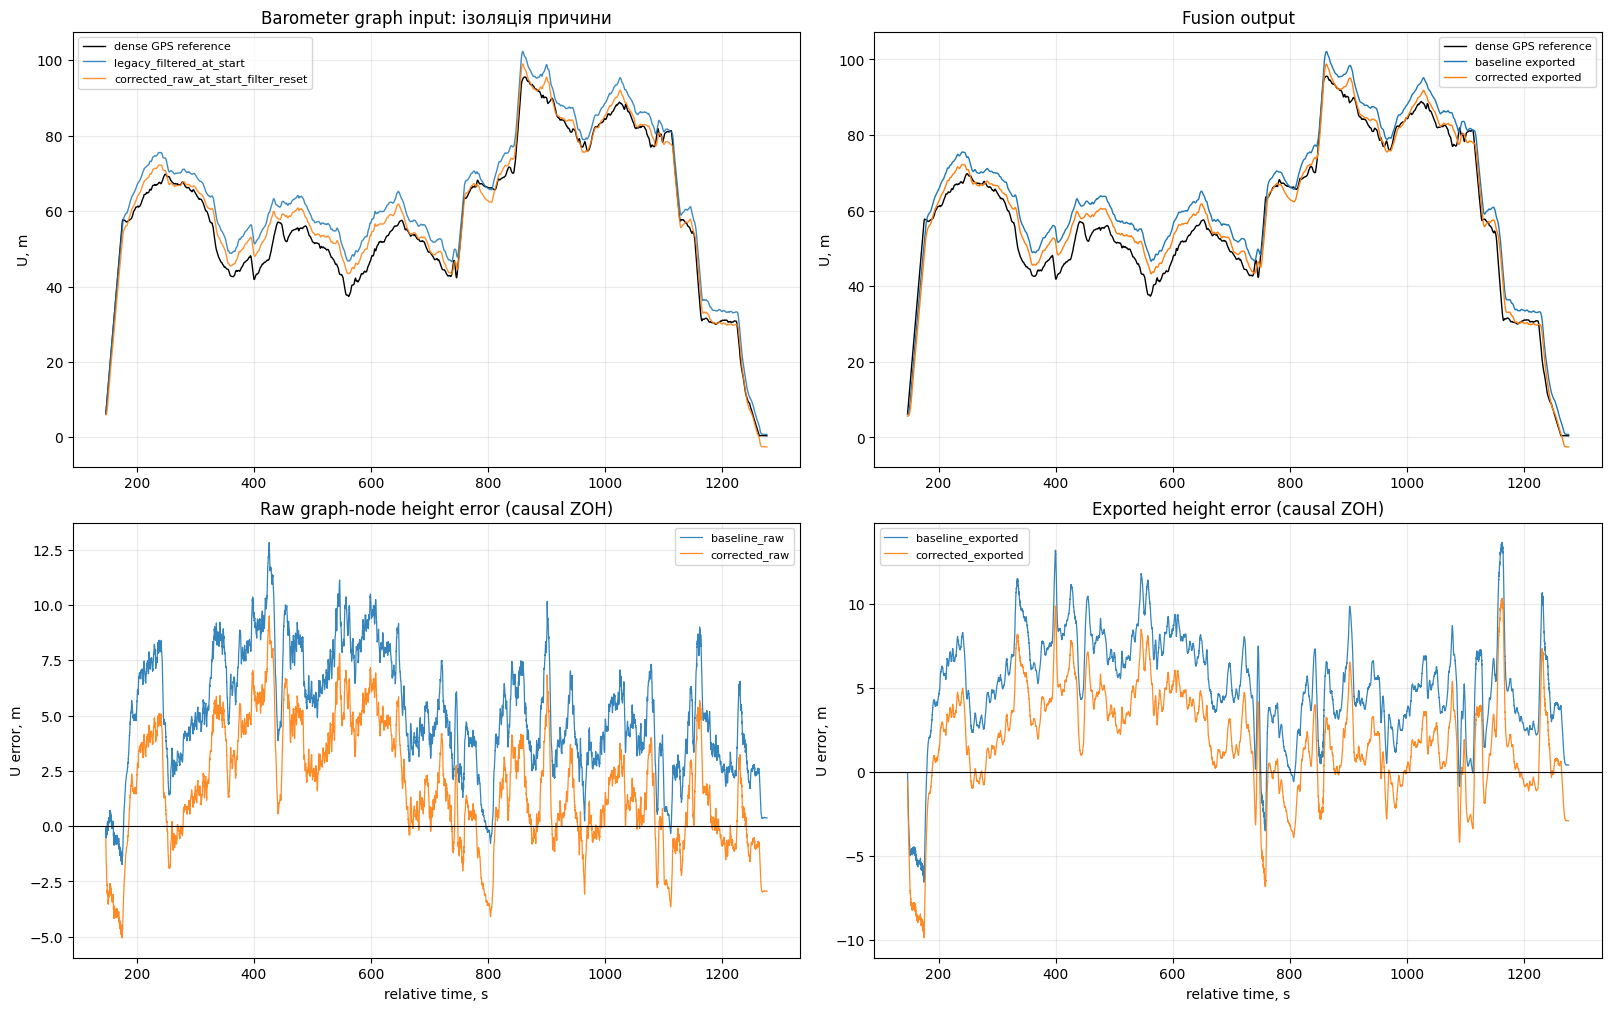

Saved plot: /home/fedor/project_cv_runtime/artifacts/height_experiments_v1/baro_alignment_v1/comparison/fusion_height_comparison.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)

active_gps = dense_gps.loc[dense_gps["tr"].between(active_start_sec, active_end_sec)]
axes[0, 0].plot(active_gps["tr"], active_gps["u"], color="black", lw=1.0, label="dense GPS reference")
for name, graph_input in barometer_comparison.graph_inputs.items():
    frame = graph_input.frame
    frame = frame.loc[frame["tr"].between(active_start_sec, active_end_sec)]
    axes[0, 0].plot(frame["tr"], frame["u_graph"], lw=1.0, alpha=0.85, label=name)
axes[0, 0].set_title("Barometer graph input: ізоляція причини")
axes[0, 0].set_ylabel("U, m")
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(alpha=0.25)

axes[0, 1].plot(active_gps["tr"], active_gps["u"], color="black", lw=1.0, label="dense GPS reference")
axes[0, 1].plot(baseline_output["tr"], baseline_output["u"], lw=1.0, label="baseline exported")
axes[0, 1].plot(corrected_output["tr"], corrected_output["u"], lw=1.0, label="corrected exported")
axes[0, 1].set_title("Fusion output")
axes[0, 1].set_ylabel("U, m")
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(alpha=0.25)

for axis, suffix, title in (
    (axes[1, 0], "raw", "Raw graph-node height error (causal ZOH)"),
    (axes[1, 1], "exported", "Exported height error (causal ZOH)"),
):
    for prefix in ("baseline", "corrected"):
        series_name = f"{prefix}_{suffix}"
        errors = fusion_alignments.loc[
            (fusion_alignments["series"] == series_name)
            & (fusion_alignments["matching_mode"] == CAUSAL_PREVIOUS_MODE)
        ]
        axis.plot(errors["tr"], errors["err_u"], lw=0.9, alpha=0.9, label=series_name)
    axis.axhline(0.0, color="black", lw=0.8)
    axis.set_title(title)
    axis.set_xlabel("relative time, s")
    axis.set_ylabel("U error, m")
    axis.legend(fontsize=8)
    axis.grid(alpha=0.25)

plot_path = COMPARISON_DIR / "fusion_height_comparison.png"
fig.savefig(plot_path, dpi=160)
plt.show()
print("Saved plot:", plot_path)

## Висновок цього етапу

Для зафіксованого dataset експеримент `raw_start_reset` зменшив causal RMSE raw-висоти приблизно з **5.77 m до 3.20 m** (−44.6%), а exported-висоти — з **6.02 m до 3.59 m** (−40.2%). Counts залишилися однаковими, `failed_updates=0`, а максимальна різниця компонент XY між відповідними вузлами — менше 9 mm.

Це підтверджує причину великої частини вертикального bias, але не означає завершеного tuning: залишкову похибку потрібно окремо дослідити на інших польотах/held-out даних, не використовуючи dense GPS як прихований fusion input. Baseline `02_sparse_gps_fusion.ipynb` цим notebook не змінюється.